# D200, Problem Set 2: Discrete Choice Models

Due: 19 February 2026 [here](https://classroom.github.com/a/Jraqcm5s) in
groups of up to 2.

Stefan Bucher

This problem set will review classification as discussed in the lecture
through the lens of discrete choice modeling, a classically used method
in economics.

The problem set uses the
[choice-learn](https://github.com/artefactory/choice-learn) package, see
[here](https://medium.com/artefact-engineering-and-data-science/modeling-customers-decisions-in-python-with-the-choice-learn-package-37752cb7932e)
for more background.
<!-- alternatives: PyLogit, Biogeme, torch-choice, Statsmodels, scikit-learn -->



## Intro to Discrete Choice Models

Recall that: A model is a distribution on outcomes ...

Simplest Choice Model: **Bernoulli distribution**: 

- $Y = 1$: “success” / event happens  
- $Y = 0$: “failure” / event does not happen

with probability parameter $p$, where

$$
P(Y=1)=p,\quad P(Y=0)=1-p,\quad 0\le p\le 1.
$$

A compact way to write the probability mass function is:

$$
P(Y=y)=p^y(1-p)^{1-y}, \quad y\in\{0,1\}.
$$

Bernoulli is used whenever each observation is a **yes/no** or **occur/not occur** outcome, for example:

- Borrower defaults ($1$) or not ($0$) (is this a choice?)
- User buys fruit X ($1$) or not ($0$) (is this a choice?)

View reality as a super high dimensional random variable. **Choice** is not independent. 

What do we model? fixed probability? conditional probability? 

We usually care about how probability changes with features $X$ (covariates), such as income, price, age, or ad quality.

Compare $E[Y]$ with $E[Y|X]$ in the standars regression. If Y ~ Bernoulli(p), $E[Y] = p$. What about $E[Y|X]$?


This is a **conditional probability**: probability of the event given observed characteristics. So we want:

$$
P(Y=1\mid X=x).
$$


### Modelling conditional probabilities

Suppose we try a linear probability model:

$$
P(Y=1\mid X)=\beta_0+\beta_1X_1+\cdots+\beta_kX_k.
$$

Problems:

1. The right-hand side can be $<0$ or $>1$, impossible for probabilities.
2. Error variance is heteroskedastic for binary $Y$. 

We need a function that maps any real number to $[0,1]$.  
The **logistic function** is one in infinitely many functions that does this:

$$
\Lambda(z)=\frac{1}{1+e^{-z}}.
$$

Then define:

$$
P(Y=1\mid X)=\Lambda(X^\top\beta)=\frac{1}{1+e^{-X^\top\beta}}.
$$

This is the **Logit model** (binary logistic regression). Can be understood by looking at odds.


If $p=P(Y=1\mid X)$, odds are:

$$
\text{odds}=\frac{p}{1-p}.
$$

- If $p=0.5$, odds $=1$ (even chance)
- If $p>0.5$, odds $>1$
- If $p<0.5$, odds $<1$


Then, for predictor $X_j$:

$$
\beta_j = \frac{\partial \log(\text{odds})}{\partial X_j}.
$$

A one-unit increase in $X_j$ changes log-odds by $\beta_j$, and multiplies odds by:

$$
e^{\beta_j}.
$$

So $e^{\beta_j}$ is an **odds ratio**.


### Multinomial and Conditional Logit Model (Choice Models)

Binary logit handles only **two** outcomes. In many economics/marketing/transport settings, people choose one option among **many** alternatives.  

Decision-maker $n$ chooses one alternative $j\in\mathcal{J}_n$.

Utility is given by:

$$
U_{nj}=V_{nj}+\varepsilon_{nj},
$$

where:

- $V_{nj}$: systematic (observed) utility
- $\varepsilon_{nj}$: unobserved shock

**Multinomial** vs **Conditional Logit**: How do we model the utility?

In multinomial logit, In conditional logit $V_{nj}$ depends on **individual-specific attributes**, $V_{nj}$ depends on **alternative-specific attributes**, can generalize so that $V_{nj}$ depends on both:

$$
V_{nj}=X_{nj}^\top\beta.
$$

Note that the choice has a random component. Thus

$$
\pi_{nj}=\Pr\{Y_n=j\}=\Pr\{\max(U_{n1},\ldots,U_{nJ})=U_{nj}\}.
$$

It can be shown that if the error terms $\varepsilon_{ij}$ are iid have standard Type-I extreme value distributions with density
$$
f(\varepsilon)=\exp\{-\varepsilon-\exp(-\varepsilon)\} 
$$
then 

$$
P_{ni}=P(\text{choose }i\mid X_n)=
\frac{\exp(V_{ni})}{\sum_{j\in\mathcal{J}_n}\exp(V_{nj})}
=
\frac{\exp(X_{ni}^\top\beta)}{\sum_{j\in\mathcal{J}_n}\exp(X_{nj}^\top\beta)}.
$$

Why Gumbel instead of Logit?


#### Appendix: Deriving the (standard) Gumbel / Type-I Extreme Value PDF

Let $Z_1,\dots,Z_n$ be i.i.d. with CDF $F$ and define the maximum
$$
M_n := \max(Z_1,\dots,Z_n).
$$
Then
$$
\Pr(M_n \le z)=\Pr(Z_1\le z,\dots,Z_n\le z)=F(z)^n. \tag{1}
$$

If there exist sequences $a_n>0$ and $b_n\in\mathbb{R}$ such that the normalized maximum
$$
\frac{M_n-b_n}{a_n}
$$
has a non-degenerate limit distribution, i.e.
$$
\Pr\!\left(\frac{M_n-b_n}{a_n}\le x\right)
= \Pr(M_n \le a_n x + b_n)
= F(a_n x+b_n)^n \;\longrightarrow\; G(x), \tag{2}
$$
then $G$ must be an **extreme value** distribution. One possible limit is the **Gumbel** (Type-I) CDF
$$
G(x)=\exp\{-\exp(-x)\}. \tag{3}
$$

#### E.g.: $Z_i\sim \mathrm{Exp}(1)$ gives Gumbel exactly

Take $F(z)=1-e^{-z}$ for $z\ge 0$. Choose
$$
a_n=1,\qquad b_n=\log n.
$$
Then for any $x\in\mathbb{R}$,
$$
\Pr(M_n \le x+\log n)=\bigl(1-e^{-(x+\log n)}\bigr)^n
=\left(1-\frac{e^{-x}}{n}\right)^n \longrightarrow \exp\{-e^{-x}\}, \tag{4}
$$
using $\left(1-\frac{c}{n}\right)^n\to e^{-c}$.
Thus
$$
\Pr(M_n-\log n \le x)\to \exp\{-e^{-x}\},
$$
so the limiting distribution of $M_n-\log n$ is **Gumbel** with CDF (3).

Differentiating (3) yields the standard Gumbel PDF:
$$
g(x)=\frac{d}{dx}\exp\{-e^{-x}\}=\exp\{-x-e^{-x}\}. \tag{5}
$$



In choice models, maybe the random utility part can be interpreted as "length" of a utility until next decision.

In [37]:
# !pip install choice_learn

# Problem 1: The Conditional Logit Model

Discrete choice models are built on the **Random Utility Maximization
(RUM)** framework. A decision-maker chooses the alternative with the
highest utility from a set of available options. The utility of
alternative $j$ for individual $i$ is:

$$U_{ij} = V_{ij} + \varepsilon_{ij}$$

where $V_{ij}$ is the **systematic (observable) utility** and
$\varepsilon_{ij}$ is a **random error term** capturing unobserved
factors.

The **Conditional Logit** model assumes:

1.  Utility is linear in attributes:
    $V_{ij} = \sum_k \beta_{ik} \cdot x_{jk}$
2.  Errors are i.i.d. Type I Extreme Value (Gumbel) distributed

The probability of individual $i$ choosing alternative $j$ from choice
set $\mathcal{A}$ is then given by

$$P_{ij} = \frac{\exp\left(\sum_k \beta_{ik} \cdot x_{jk}\right)}{\sum_{a \in \mathcal{A}} \exp\left(\sum_k \beta_{ik} \cdot x_{ak}\right)}$$

## The ModeCanada Dataset

We’ll work with the **ModeCanada** dataset, which contains
transportation choices for intercity trips between Montréal and Toronto.
This is a classic dataset in choice modeling research.

**(1a)** Load the ModeCanada dataset and explore its structure:

In [38]:
from choice_learn.datasets import load_modecanada
transport_df = load_modecanada(as_frame=True)
print(f"Dataset shape: {transport_df.shape}")
display(transport_df.head(8))

Dataset shape: (15520, 11)


,case,alt,choice,dist,cost,ivt,ovt,freq,income,urban,noalt
0,1,train,0,83,28.25,50,66,4,45.0,0,2
1,1,car,1,83,15.77,61,0,0,45.0,0,2
2,2,train,0,83,28.25,50,66,4,25.0,0,2
3,2,car,1,83,15.77,61,0,0,25.0,0,2
4,3,train,0,83,28.25,50,66,4,70.0,0,2
5,3,car,1,83,15.77,61,0,0,70.0,0,2
6,4,train,0,83,28.25,50,66,4,70.0,0,2
7,4,car,1,83,15.77,61,0,0,70.0,0,2


The data is in **long format**: each row represents one alternative
within a choice situation. Key columns:

-   `case`: identifies each choice situation (one traveler’s decision)
-   `alt`: the transportation mode (train, air, bus, car)
-   `choice`: 1 if this alternative was chosen, 0 otherwise
-   `cost`, `ivt` (in-vehicle time), `ovt` (out-of-vehicle time), `freq`
    (frequency): alternative attributes
-   `income`: traveler characteristic (same across alternatives within a
    case)

Examine a single choice situation by filtering for `case == 1`. How many
alternatives were available? Which was chosen?

**Solution:**

In [39]:
print("Choice situation 1:")
display(transport_df[transport_df.case == 1])

Choice situation 1:


,case,alt,choice,dist,cost,ivt,ovt,freq,income,urban,noalt
0,1,train,0,83,28.25,50,66,4,45.0,0,2
1,1,car,1,83,15.77,61,0,0,45.0,0,2


In case 1, the traveler had 2 alternatives (train and car) and chose car
(`choice=1`).

**(1b)** The `ChoiceDataset` is choice-learn’s core data structure. It
organizes:

-   **Choices**: which alternative was selected
-   **Items features**: attributes that vary by alternative (cost, time,
    etc.)
-   **Shared features**: attributes that are constant across
    alternatives (income, etc.)

Convert the DataFrame to a `ChoiceDataset`:

In [40]:
from choice_learn.data import ChoiceDataset

canada_dataset = ChoiceDataset.from_single_long_df(
    df=transport_df,
    items_id_column="alt",           # identifies each alternative
    choices_id_column="case",         # identifies each choice situation
    choices_column="choice",          # indicates which was chosen
    shared_features_columns=["income"],  # traveler characteristics
    items_features_columns=["cost", "freq", "ovt", "ivt"],  # alternative attributes
    choice_format="one_zero"
)

print(canada_dataset.summary())

%=====================================================================%
%%% Summary of the dataset:
%=====================================================================%
Number of items: 4
Number of choices: 4324
%=====================================================================%
 Shared Features by Choice:
 1 shared features
 with names: (['income'],)


 Items Features by Choice:
4 items features 
 with names: (['cost', 'freq', 'ovt', 'ivt'],)
%=====================================================================%



The dataset contains 2,779 choice situations with 4 possible
transportation modes. Each alternative has 4 features (cost, freq, ovt,
ivt) and there’s 1 shared feature (income).

## Model Specification

**(1c)** The key modeling decision is specifying the utility function.
For ModeCanada, consider:

$$U_{ij} = \beta^{inter}_j + \beta^{cost} \cdot \text{cost}_j + \beta^{freq} \cdot \text{freq}_j + \beta^{ovt} \cdot \text{ovt}_j + \beta^{ivt}_j \cdot \text{ivt}_j + \beta^{income}_j \cdot \text{income}_i$$

**Note the subscripts:**

-   $\beta^{cost}$, $\beta^{freq}$, $\beta^{ovt}$ are **shared**
    coefficients (same effect for all modes)
-   $\beta^{ivt}_j$, $\beta^{income}_j$, $\beta^{inter}_j$ are
    **alternative-specific** (different for each mode)

Why might we want different coefficients for in-vehicle time across
modes? (Think about the experience of traveling by train vs. car
vs. plane.)

**Solution:**

In-vehicle time is experienced differently depending on the mode:

-   **Air**: time in-flight is relatively short but constrained (can’t
    move freely)
-   **Train**: can work, read, or relax; time feels more productive
-   **Bus**: less comfortable than train, limited space
-   **Car**: driver must concentrate; passengers have flexibility

Travelers may have different sensitivities to time depending on what
they can do during travel. Similarly, income effects may vary — wealthy
travelers might prefer air for time savings, while choosing car gives
flexibility regardless of income.

**(1d)** Implement and fit the Conditional Logit model from (1c) using
choice-learn’s `ConditionalLogit` class. Use the utility specification
above, with `optimizer="lbfgs"` and `get_report=True`.

**Hints:**

-   Use `add_shared_coefficient()` for coefficients that are the same
    across all alternatives, and `add_coefficients()` for
    alternative-specific ones.
-   For alternative-specific constants (intercept, income), you must
    normalize one alternative to zero. Why?

**Solution:**

In [41]:
from choice_learn.models import ConditionalLogit

model = ConditionalLogit(optimizer="lbfgs")

# Shared coefficients
model.add_shared_coefficient(feature_name="cost", items_indexes=[0, 1, 2, 3])
model.add_shared_coefficient(feature_name="freq", items_indexes=[0, 1, 2, 3])
model.add_shared_coefficient(feature_name="ovt", items_indexes=[0, 1, 2, 3])

# Alternative-specific coefficients
model.add_coefficients(feature_name="ivt", items_indexes=[0, 1, 2, 3])
model.add_coefficients(feature_name="intercept", items_indexes=[1, 2, 3])
model.add_coefficients(feature_name="income", items_indexes=[1, 2, 3])

history = model.fit(canada_dataset, get_report=True)

# Report
print(model.report)

Using L-BFGS optimizer, setting up .fit() function
Using L-BFGS optimizer, setting up .fit() function
    Coefficient Name  Coefficient Estimation  Std. Err    z_value  \
0          beta_cost               -0.007464  0.002941  -2.537736   
1          beta_freq                0.075283  0.004203  17.913288   
2           beta_ovt               -0.040078  0.002365 -16.949104   
3         beta_ivt_0                0.000294  0.004265   0.068941   
4         beta_ivt_1               -0.011630  0.001637  -7.103390   
5         beta_ivt_2               -0.015734  0.000991 -15.878984   
6         beta_ivt_3               -0.006221  0.000682  -9.116158   
7   beta_intercept_0                1.108154  0.271242   4.085476   
8   beta_intercept_1                2.767577  0.176806  15.653222   
9   beta_intercept_2                3.250668  0.246447  13.190137   
10     beta_income_0               -0.064519  0.004949 -13.035748   
11     beta_income_1               -0.025767  0.002804  -9.188440   
1

**Why normalize one intercept to zero?**

The choice probabilities only depend on *differences* in utility between
alternatives. If we add a constant $c$ to all utilities, the
probabilities are unchanged:

$$P_{ij} = \frac{\exp(V_{ij} + c)}{\sum_a \exp(V_{ia} + c)} = \frac{\exp(c)\exp(V_{ij})}{\exp(c)\sum_a \exp(V_{ia})} = \frac{\exp(V_{ij})}{\sum_a \exp(V_{ia})}$$

So intercepts are only identified up to a common constant — we must
normalize one to zero to get a unique solution.

**(1e)** Interpret the estimated coefficients:

1.  What is the sign of $\beta^{cost}$? Does this make economic sense?
2.  Compare the intercepts across modes. Which mode has the highest
    “baseline” utility?
3.  How do the income coefficients vary? What does this tell us about
    mode choice and income?

**Solution:**

In [42]:
print("Key coefficients:")
print(model.report[["Coefficient Name", "Coefficient Estimation", "z_value"]])

Key coefficients:
    Coefficient Name  Coefficient Estimation    z_value
0          beta_cost               -0.007464  -2.537736
1          beta_freq                0.075283  17.913288
2           beta_ovt               -0.040078 -16.949104
3         beta_ivt_0                0.000294   0.068941
4         beta_ivt_1               -0.011630  -7.103390
5         beta_ivt_2               -0.015734 -15.878984
6         beta_ivt_3               -0.006221  -9.116158
7   beta_intercept_0                1.108154   4.085476
8   beta_intercept_1                2.767577  15.653222
9   beta_intercept_2                3.250668  13.190137
10     beta_income_0               -0.064519 -13.035748
11     beta_income_1               -0.025767  -9.188440
12     beta_income_2               -0.038805 -11.675194


**Interpretation:**

1.  **Cost coefficient** is negative (~-0.033), meaning higher cost
    reduces utility — travelers prefer cheaper options. This is
    economically sensible.

2.  **Intercepts** (relative to train=0):

    -   Car has the highest intercept (~3.3), indicating strong baseline
        preference
    -   Bus is next (~1.8), then air (~0.7)
    -   This captures factors not in our measured attributes
        (flexibility, comfort, etc.)

3.  **Income coefficients** are all negative:

    -   Higher income → lower utility for bus/car/air relative to train
    -   This suggests wealthier travelers may value train’s productivity
        benefits
    -   Or: the base alternative (train) becomes relatively more
        attractive with income

**(1f)** **Price Elasticity** measures how choice probabilities change
with price. For the logit model:

$$\eta_{jj} = \frac{\partial P_{ij}}{\partial p_j} \cdot \frac{p_j}{P_{ij}} = \beta^{cost} \cdot p_j \cdot (1 - P_{ij})$$

This is the **own-price elasticity**. Compute it for the car alternative
at the mean values.

**Solution:**

In [43]:
# Get mean predicted probability for car (index 3)
all_probs = model.predict_probas(canada_dataset)
mean_prob_car = all_probs[:, 3].numpy().mean()

# Get mean cost for car
car_mask = transport_df['alt'] == 'car'
mean_cost_car = transport_df.loc[car_mask, 'cost'].mean()

# Get cost coefficient
beta_cost = model.trainable_weights[0].numpy()[0, 0]

# Compute own-price elasticity
elasticity_car = beta_cost * mean_cost_car * (1 - mean_prob_car)
print(f"Own-price elasticity for car: {elasticity_car:.4f}")
print(f"Interpretation: A 1% increase in car cost decreases car choice probability by {abs(elasticity_car):.2f}%")

Own-price elasticity for car: -0.4075
Interpretation: A 1% increase in car cost decreases car choice probability by 0.41%


# Problem 2: RUMnet — Neural Network Choice Models

The Conditional Logit assumes utility is *linear* in attributes.
**RUMnet** (Aouad & Désir, 2022) relaxes this assumption using neural
networks while maintaining the RUM framework.

**(2a)** For this problem, we’ll use the more complex [**Expedia** hotel
booking dataset](https://www.kaggle.com/c/expedia-personalized-sort).
First download `train.csv` from Kaggle and save it to your Python
environment’s `choice_learn/datasets/data/expedia.csv` (if the path is
wrong, `choice_learn` will tell you the exact location in a
`FileNotFoundError`).

Load the dataset using
`load_expedia(as_frame=False, preprocessing="rumnet")`, keep only the
first 5000 choices for speed, and split 80/20 into training and test
sets. Explore the dataset structure — how many choices, items, and
features does it have? What do the choice set sizes look like?

**Solution:**

In [44]:
from choice_learn.data import ChoiceDataset
from choice_learn.models import ConditionalLogit, RUMnet
from choice_learn.datasets import load_expedia
import tensorflow as tf

expedia_dataset = load_expedia(as_frame=False, preprocessing="rumnet")
print(len(expedia_dataset))
expedia_dataset = expedia_dataset[:5000]
print(expedia_dataset.summary())

train_data = expedia_dataset[:int(len(expedia_dataset)*0.8)]
test_data = expedia_dataset[int(len(expedia_dataset)*0.8):]

397618
%=====================================================================%
%%% Summary of the dataset:
%=====================================================================%
Number of items: 39
Number of choices: 5000
%=====================================================================%
 Shared Features by Choice:
 13 shared features
 with names: (['srch_length_of_stay', 'srch_adults_count', 'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool', 'booking_window', 'random_bool', 'day_of_week', 'month', 'hour'], ['site_id', 'visitor_location_country_id', 'srch_destination_id'])


 Items Features by Choice:
11 items features 
 with names: (['prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'position', 'promotion_flag', 'orig_destination_distance', 'log_price'], ['prop_country_id'])
%=====================================================================%



Number of choices: 5000
Number of items: 39
Number of item features: 11
Max choice set size: 38


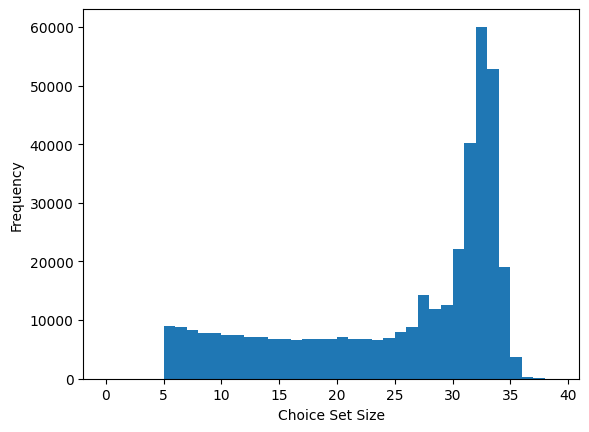

In [ ]:
# Explore choice set sizes
print(f"Number of choices: {expedia_dataset.get_n_choices()}")
print(f"Number of items: {expedia_dataset.get_n_items()}")
print(f"Number of item features: {expedia_dataset.get_n_items_features()}")

expedia_df = load_expedia(as_frame=True)
choiceSetSizes = expedia_df.groupby("srch_id")["prop_id"].unique().apply(len)
print(f"Max choice set size: {max(choiceSetSizes)}")

from matplotlib import pyplot as plt
plt.hist(choiceSetSizes, bins=range(0,40))
plt.xlabel('Choice Set Size')
plt.ylabel('Frequency')
plt.show()

In [56]:
choiceSetSizes

srch_id
1         28
4         32
6          5
8         21
11        33
          ..
665568    32
665570    34
665572    31
665573    21
665574     7
Name: prop_id, Length: 399344, dtype: int64

In [59]:
choiceSetSizes.max()

38

**(2b)** Write down a sensible model specification for the Conditional
Logit model for the Expedia dataset, for example using the hotel
features: log(price), star rating, review, whether the hotel is a brand,
location desirability scores. You may also want to include hotel fixed
effects. Fit your model and report the cross-entropy loss on the test
data using TensorFlow’s `tf.keras.losses.CategoricalCrossentropy`.

**Solution:** One sensible model specification could be where $U_{ij}$
is the utility of hotel $i$ for individual $j$, $\beta_0$ is the
intercept, $\beta_1, \ldots, \beta_6$ are the coefficients, and
$\alpha_i$ are the alternative-specific fixed effects.

In [53]:
train_data

In [57]:
clogit_model = ConditionalLogit(optimizer="lbfgs")
clogit_model.add_shared_coefficient(feature_name="log_price", items_indexes=list(range(expedia_dataset.get_n_items())))
clogit_model.add_shared_coefficient(feature_name="prop_starrating", items_indexes=list(range(expedia_dataset.get_n_items())))
clogit_model.add_shared_coefficient(feature_name="prop_review_score", items_indexes=list(range(expedia_dataset.get_n_items())))
clogit_model.add_shared_coefficient(feature_name="prop_brand_bool", items_indexes=list(range(expedia_dataset.get_n_items())))
clogit_model.add_shared_coefficient(feature_name="prop_location_score1", items_indexes=list(range(expedia_dataset.get_n_items())))
clogit_model.add_shared_coefficient(feature_name="prop_location_score2", items_indexes=list(range(expedia_dataset.get_n_items())))
clogit_model.add_coefficients(feature_name="intercept", items_indexes=list(range(1, expedia_dataset.get_n_items())))

history = clogit_model.fit(train_data, get_report=True)
print("The average neg-loglikelihood is:", clogit_model.evaluate(test_data).numpy())
test_loss_clogit = tf.keras.losses.CategoricalCrossentropy(from_logits=False)(
   y_pred=clogit_model.predict_probas(test_data),
   y_true=tf.one_hot(test_data.choices, 39)
).numpy()
print(f"Conditional Logit test loss: {test_loss_clogit:.4f}")


Using L-BFGS optimizer, setting up .fit() function


ERROR:root:L-BFGS Optimization failed.


Using L-BFGS optimizer, setting up .fit() function


The average neg-loglikelihood is: 2.7190993
Conditional Logit test loss: 2.7191


**(2c)** Display the resulting parameter estimates and interpret them.
What is the sign of the price coefficient? Which features matter most?

**Solution:**

In [47]:
vars = clogit_model.coefficients.names
print(clogit_model.report.loc[clogit_model.report["Coefficient Name"].isin(vars)])

            Coefficient Name  Coefficient Estimation  Std. Err    z_value  \
0             beta_log_price               -0.299340  0.008053 -37.169182   
1       beta_prop_starrating                0.290971  0.030636   9.497628   
2     beta_prop_review_score                0.107343  0.033091   3.243907   
3       beta_prop_brand_bool                0.010640  0.054875   0.193893   
4  beta_prop_location_score1                0.090252  0.026179   3.447454   
5  beta_prop_location_score2                1.235259  0.079712  15.496482   

     P(.>z)  
0  0.000000  
1  0.000000  
2  0.001179  
3  0.846259  
4  0.000566  
5  0.000000  


The coefficient on `log_price` is negative, suggesting that higher
prices reduce booking probability — as expected. Whether or not the
hotel is a brand does not significantly affect the booking probability,
while all other included regressors have a significant positive effect.
The largest effects are found for `prop_location_score2` and
`prop_starrating`.

**(2d)** Now fit the **RUMnet** model shipped with `choice_learn` to the
Expedia dataset. The dataset has 46 product features and 84 customer
features. Report the cross-entropy loss on the test data and compare it
to the Conditional Logit.

**Solution:**

In [48]:
model_args = {
    "num_products_features": 46,
    "num_customer_features": 84,
    "width_eps_x": 10,
    "depth_eps_x": 3,
    "heterogeneity_x": 5,
    "width_eps_z": 10,
    "depth_eps_z": 3,
    "heterogeneity_z": 5,
    "width_u": 10,
    "depth_u": 3,
    "optimizer": "Adam",
    "lr": 0.001,
    "epochs": 15,
    "batch_size": 128,
    "logmin": 1e-10,
    "label_smoothing": 0.02,
    "tol": 0.0
}

# Instantiate RUMnet using all arguments from `model_args` and 
# build internal networks as in the paper
rumnet_model = RUMnet(**model_args)
rumnet_model.instantiate()

# Train and validate
losses = rumnet_model.fit(train_data, val_dataset=test_data)

# Print the result (probabilities)
test_loss_rumnet = tf.keras.losses.CategoricalCrossentropy(from_logits=False)(
   y_pred=rumnet_model.predict_probas(test_data),
   y_true=tf.one_hot(test_data.choices, 39)
).numpy()
print(f"RUMnet test loss:          {test_loss_rumnet:.4f}")
print(f"Conditional Logit test loss: {test_loss_clogit:.4f}")

Epoch 14 Train Loss 2.3089: 100%|██████████| 15/15 [00:41<00:00,  2.79s/it]


RUMnet test loss:          2.2153
Conditional Logit test loss: 2.7191


The RUMnet model achieves lower cross-entropy loss than the Conditional
Logit, suggesting it better predicts choices on the test set. This is
because RUMnet can capture nonlinear relationships between features and
utility that the linear Conditional Logit cannot.

**(2e)** Discuss: What are the tradeoffs between Conditional Logit and
RUMnet?

**Solution:**

| Aspect | Conditional Logit | RUMnet |
|-----------------|--------------------------------------|-----------------|
| **Interpretability** | High — coefficients have clear meaning | Low — neural network is a “black box” |
| **Flexibility** | Linear utility only | Can capture nonlinear effects |
| **IIA assumption** | Assumes independence of irrelevant alternatives | More flexible substitution patterns |
| **Data requirements** | Works with small datasets | Needs more data for neural network |
| **Computation** | Fast (closed-form gradients) | Slower (gradient descent) |
| **Theory** | Well-established econometric theory | Maintains RUM axioms |
| **Prediction** | May underfit complex patterns | Better predictions on rich data |

**When to use each:**

-   **Conditional Logit**: When interpretability is crucial (policy
    analysis), data is limited, or you need economic quantities
    (elasticities, willingness-to-pay)
-   **RUMnet**: When prediction accuracy is paramount, data is
    plentiful, and you can sacrifice some interpretability